In [1]:
# Random Forest:

In [2]:
# Dataset Description:
# Use the Glass dataset and apply the Random forest model.

In [3]:
# 1. Exploratory Data Analysis (EDA):
# Perform exploratory data analysis to understand the structure of the dataset.
# Check for missing values, outliers, inconsistencies in the data.

In [4]:
# Load the Dataset 
import pandas as pd 
df = pd.read_excel("glass.xlsx", sheet_name="glass")

In [5]:
df['Type'].unique()

array([1, 2, 3, 5, 6, 7])

In [6]:
# Head of the Dataset 
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [7]:
# Tail of the Dataset 
df.tail()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
209,1.51623,14.14,0.0,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.0,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.0,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.0,1.94,73.61,0.00,8.48,1.57,0.0,7
213,1.51711,14.23,0.0,2.08,73.36,0.00,8.62,1.67,0.0,7


In [8]:
# Shape of the Dataset 
df.shape

(214, 10)

In [9]:
# Columns of the dataset 
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [10]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [11]:
# Statistical Summary 
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [12]:
# Check Missing Values 
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [13]:
# Check Duplicates 
df.duplicated().sum()

np.int64(1)

In [14]:
# Drop Duplicates 
df.drop_duplicates(inplace = True)

In [15]:
# Verify 
df.duplicated().sum()

np.int64(0)

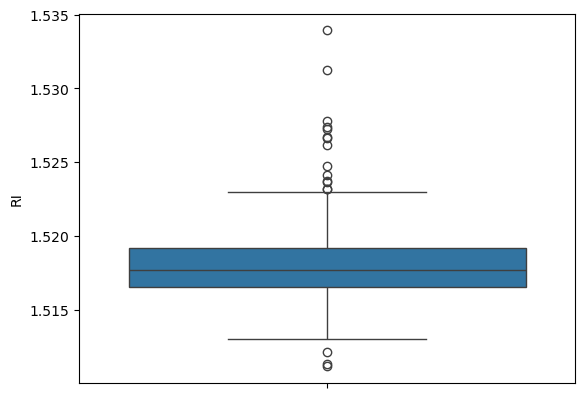

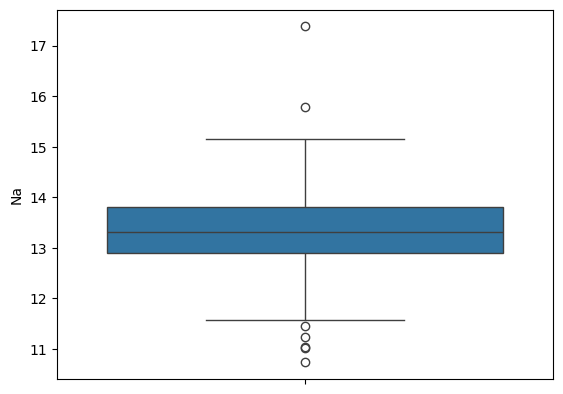

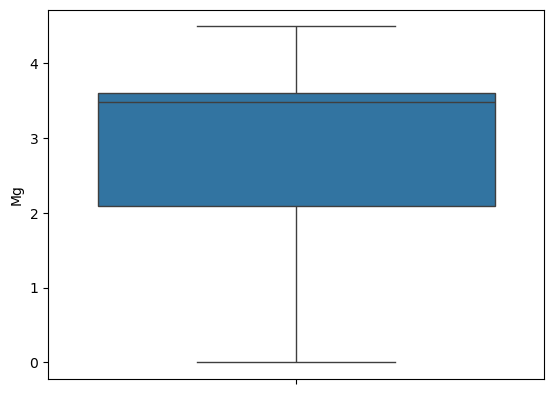

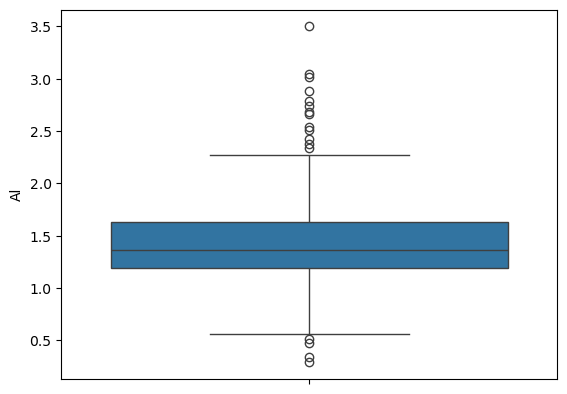

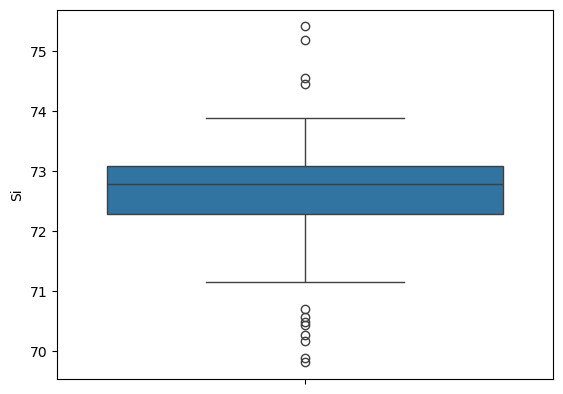

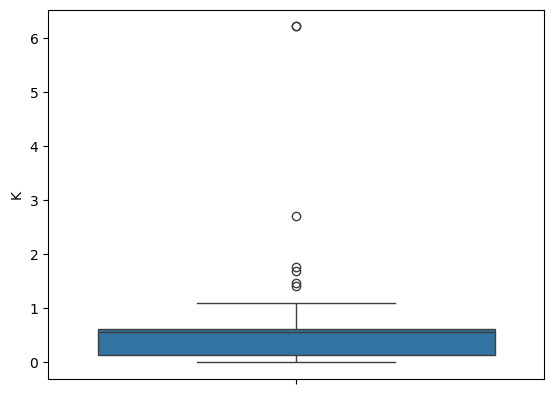

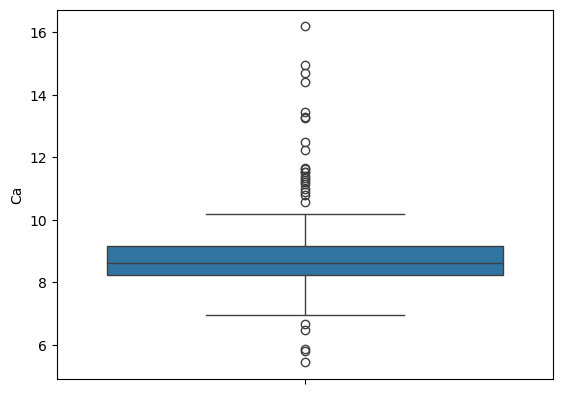

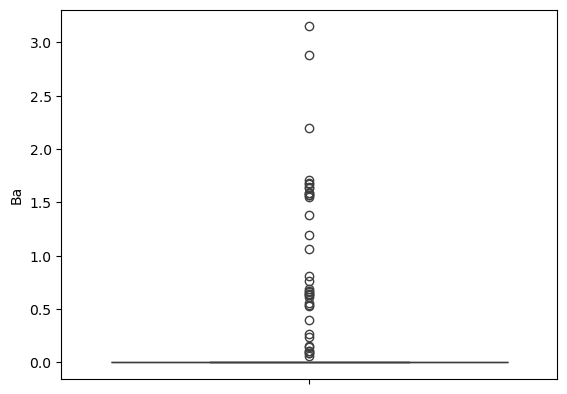

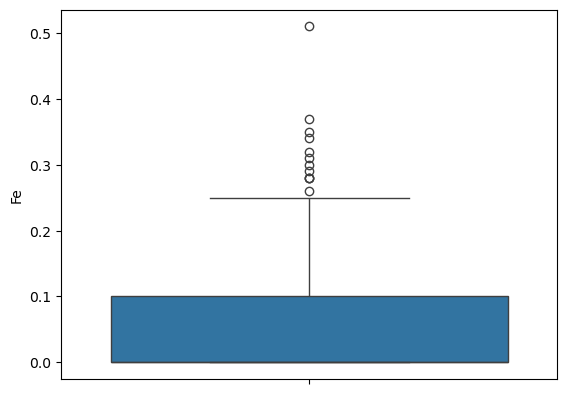

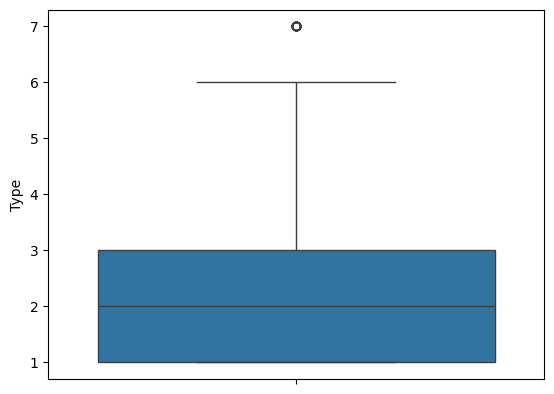

In [16]:
# Check Oitliers 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

In [17]:
# Ouitlier Capping 
for i in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    IQR  = q1 - q3 
    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5*IQR

    df[i] = df[i].clip(lower_bound, upper_bound)

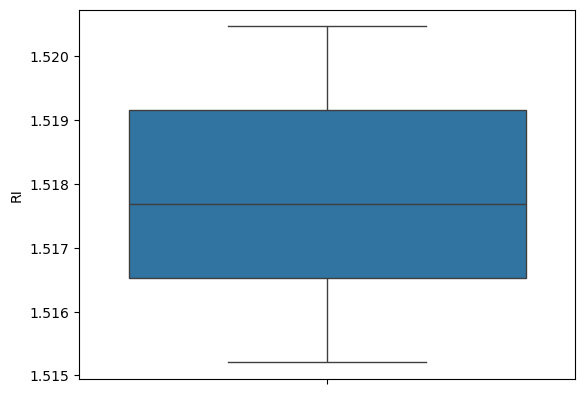

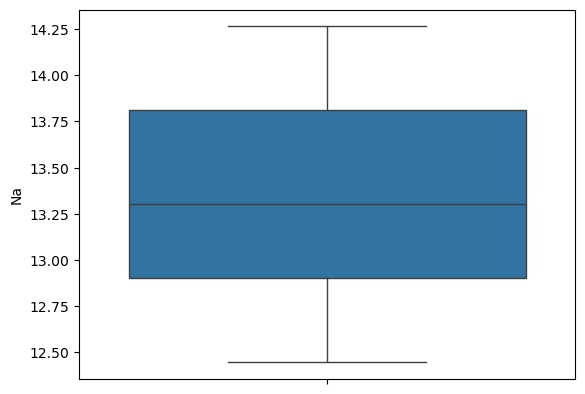

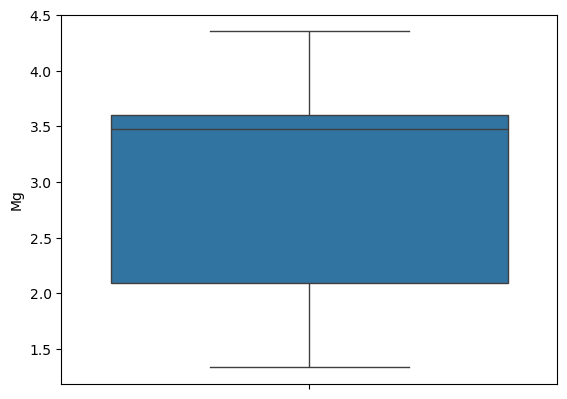

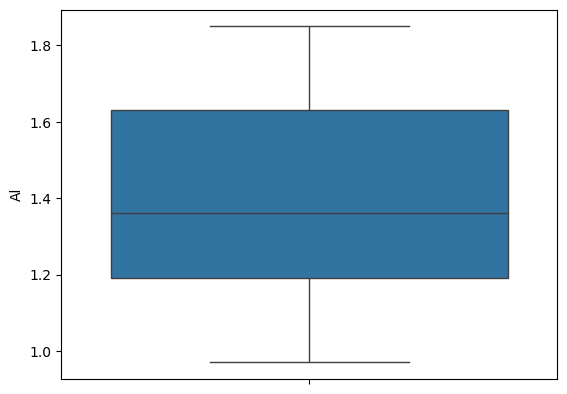

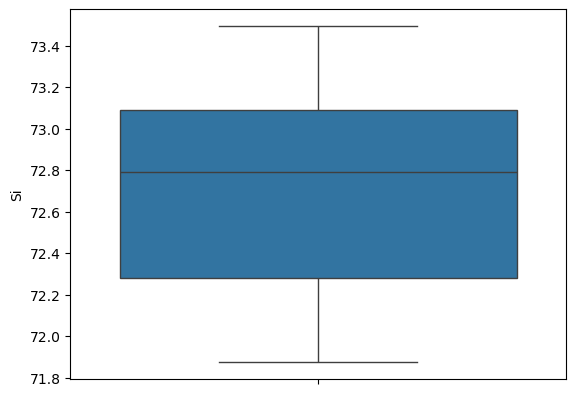

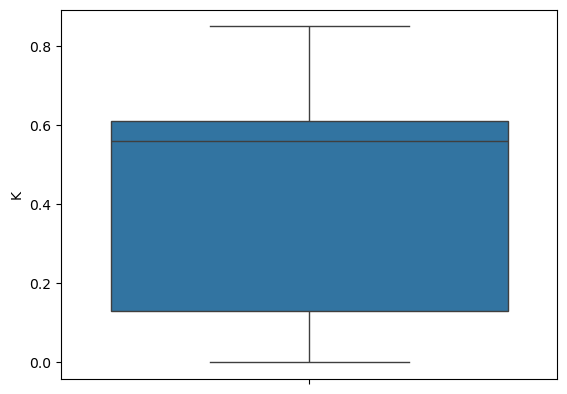

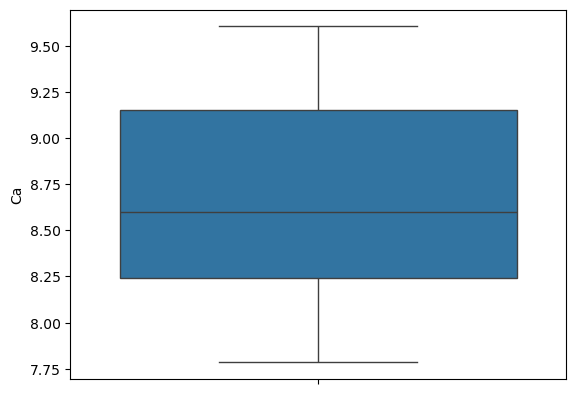

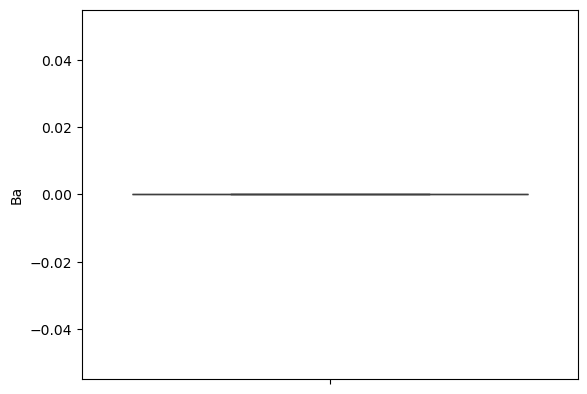

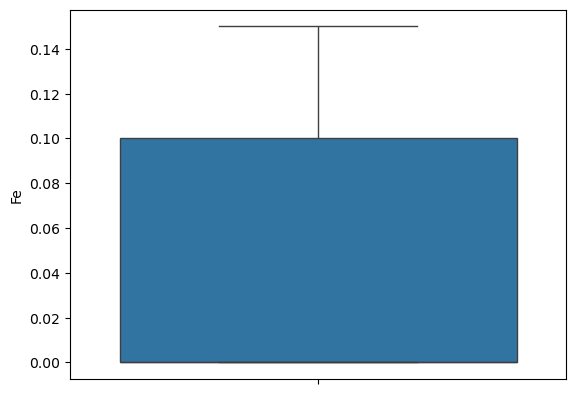

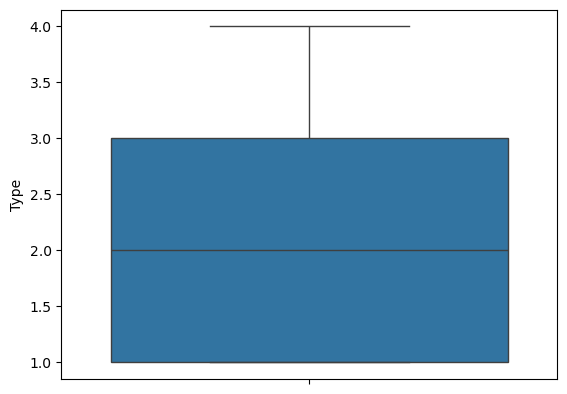

In [18]:
# Verify 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

In [19]:
# # 2: Data Visualization:
# Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
# Analyze any patterns or correlations observed in the data.

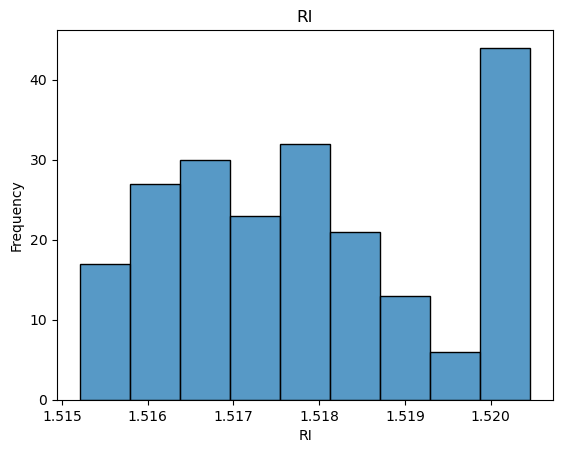

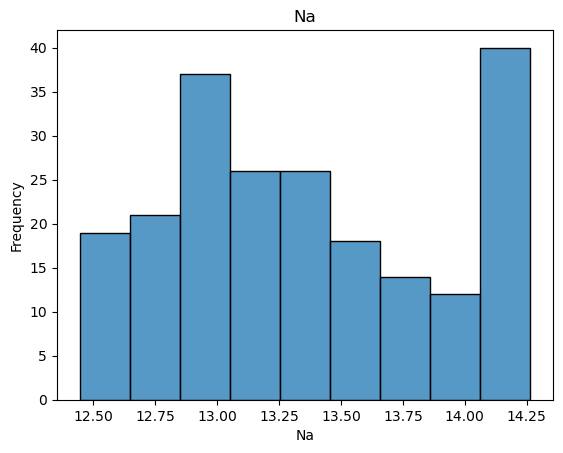

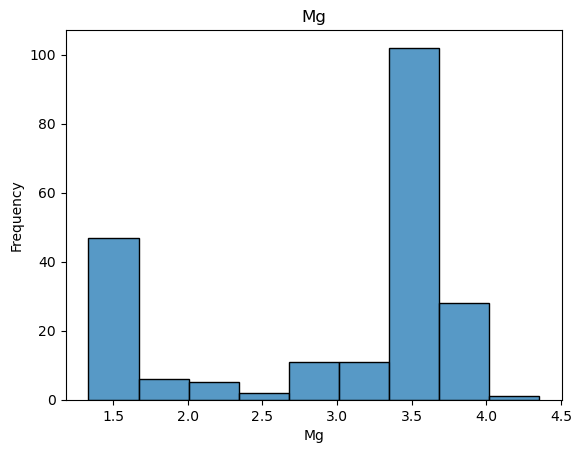

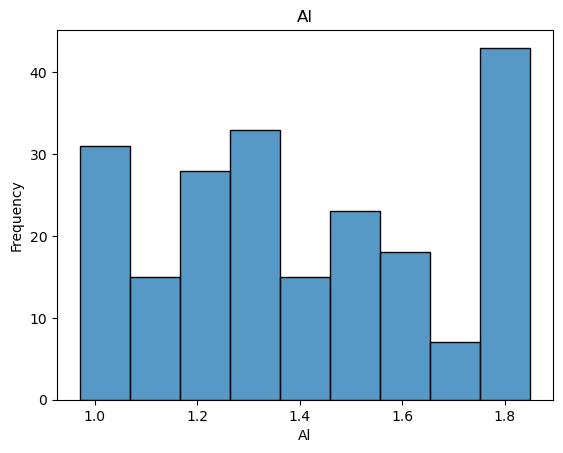

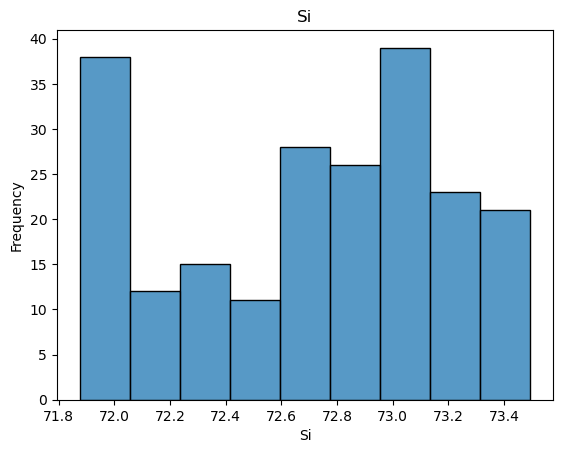

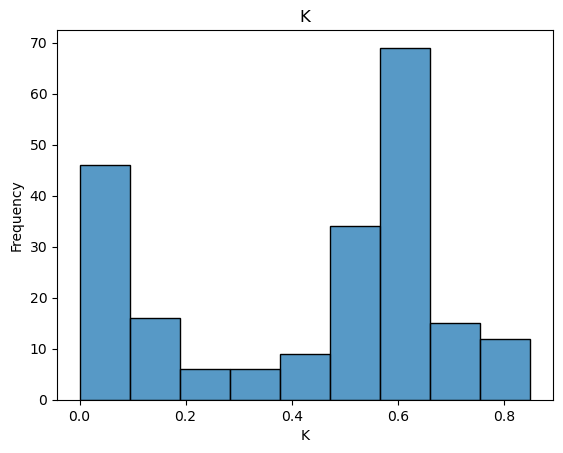

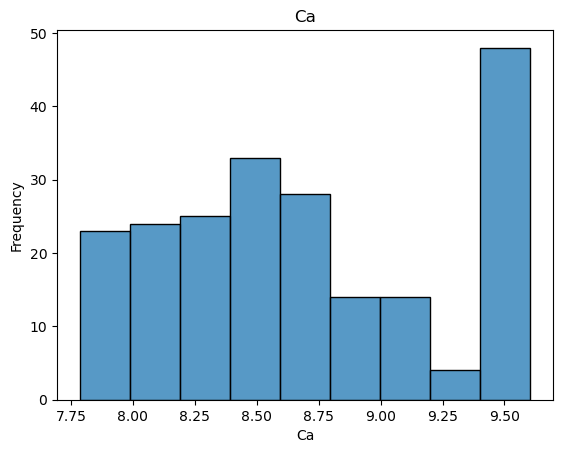

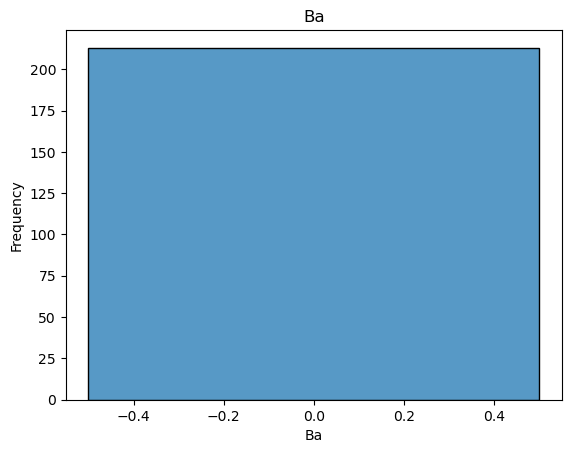

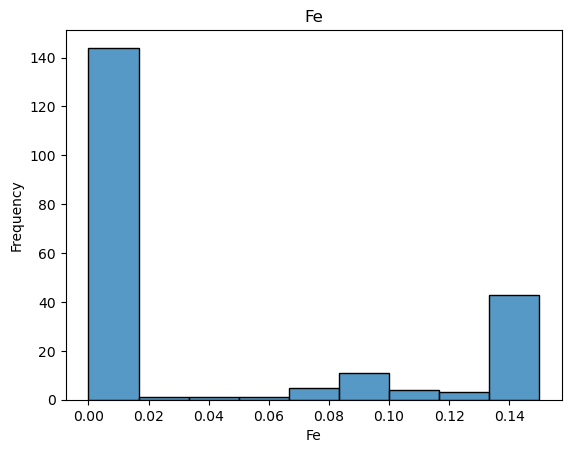

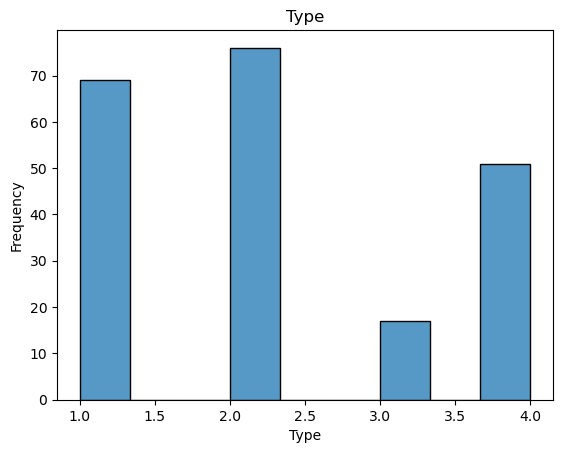

In [20]:
# HIST PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.histplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

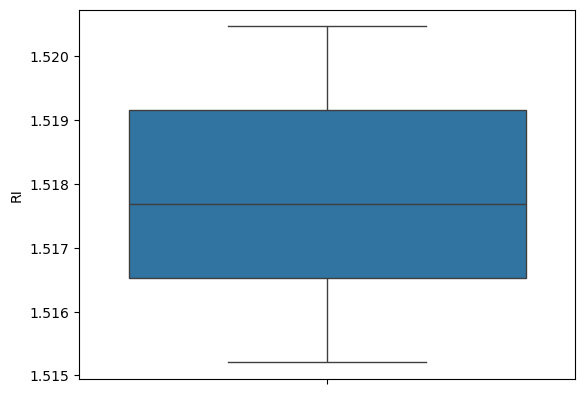

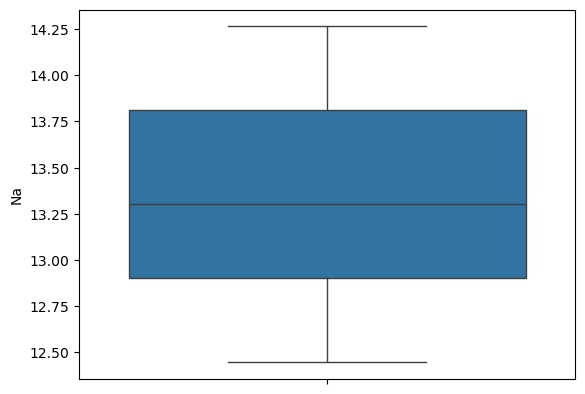

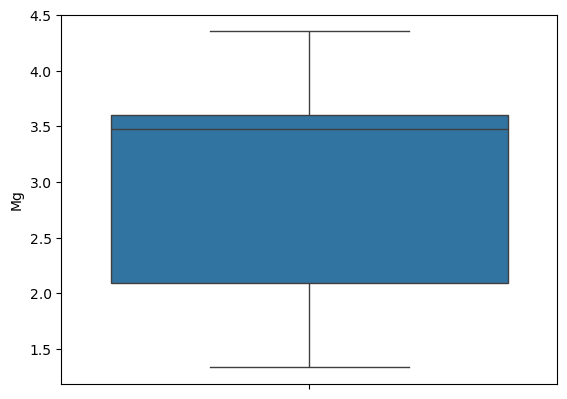

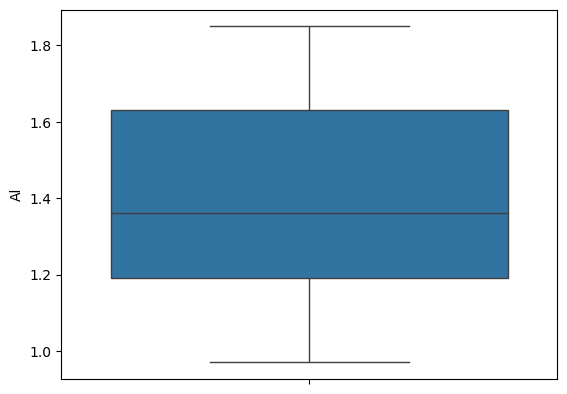

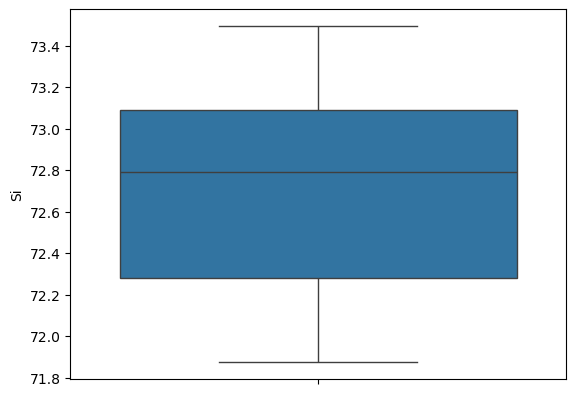

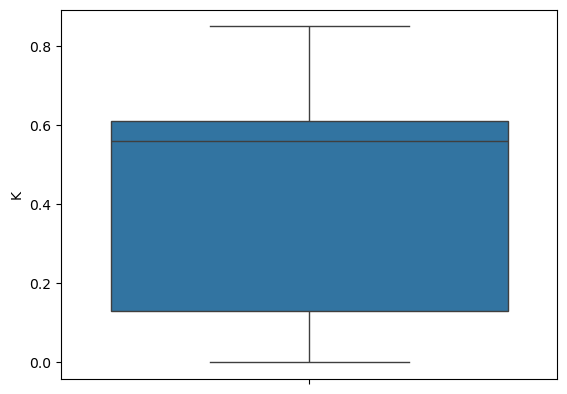

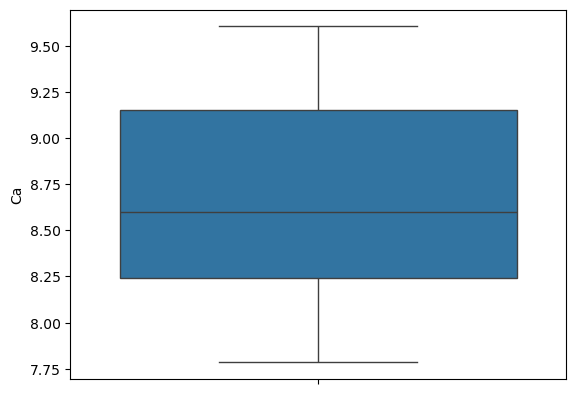

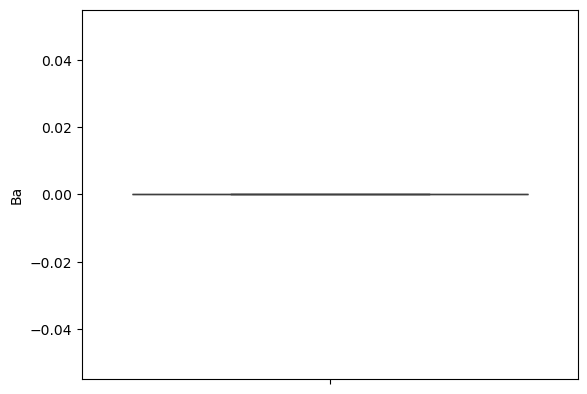

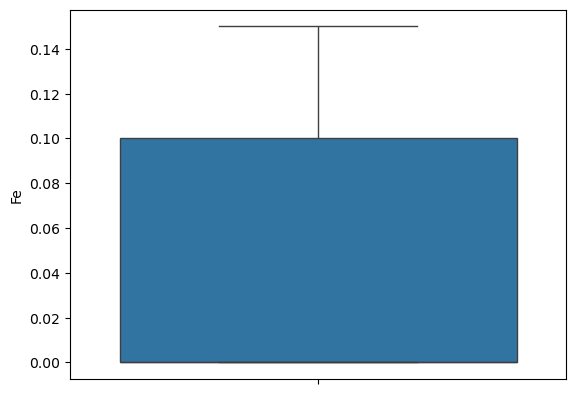

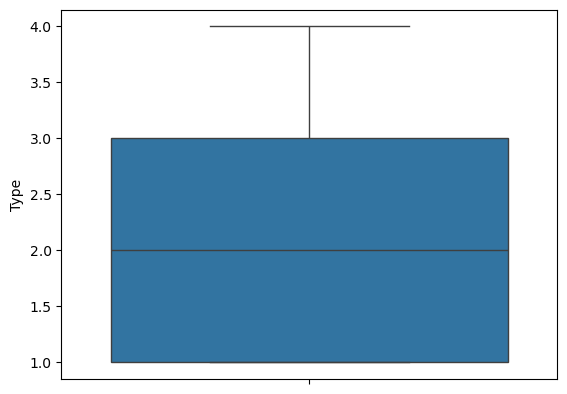

In [21]:
# BOX PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

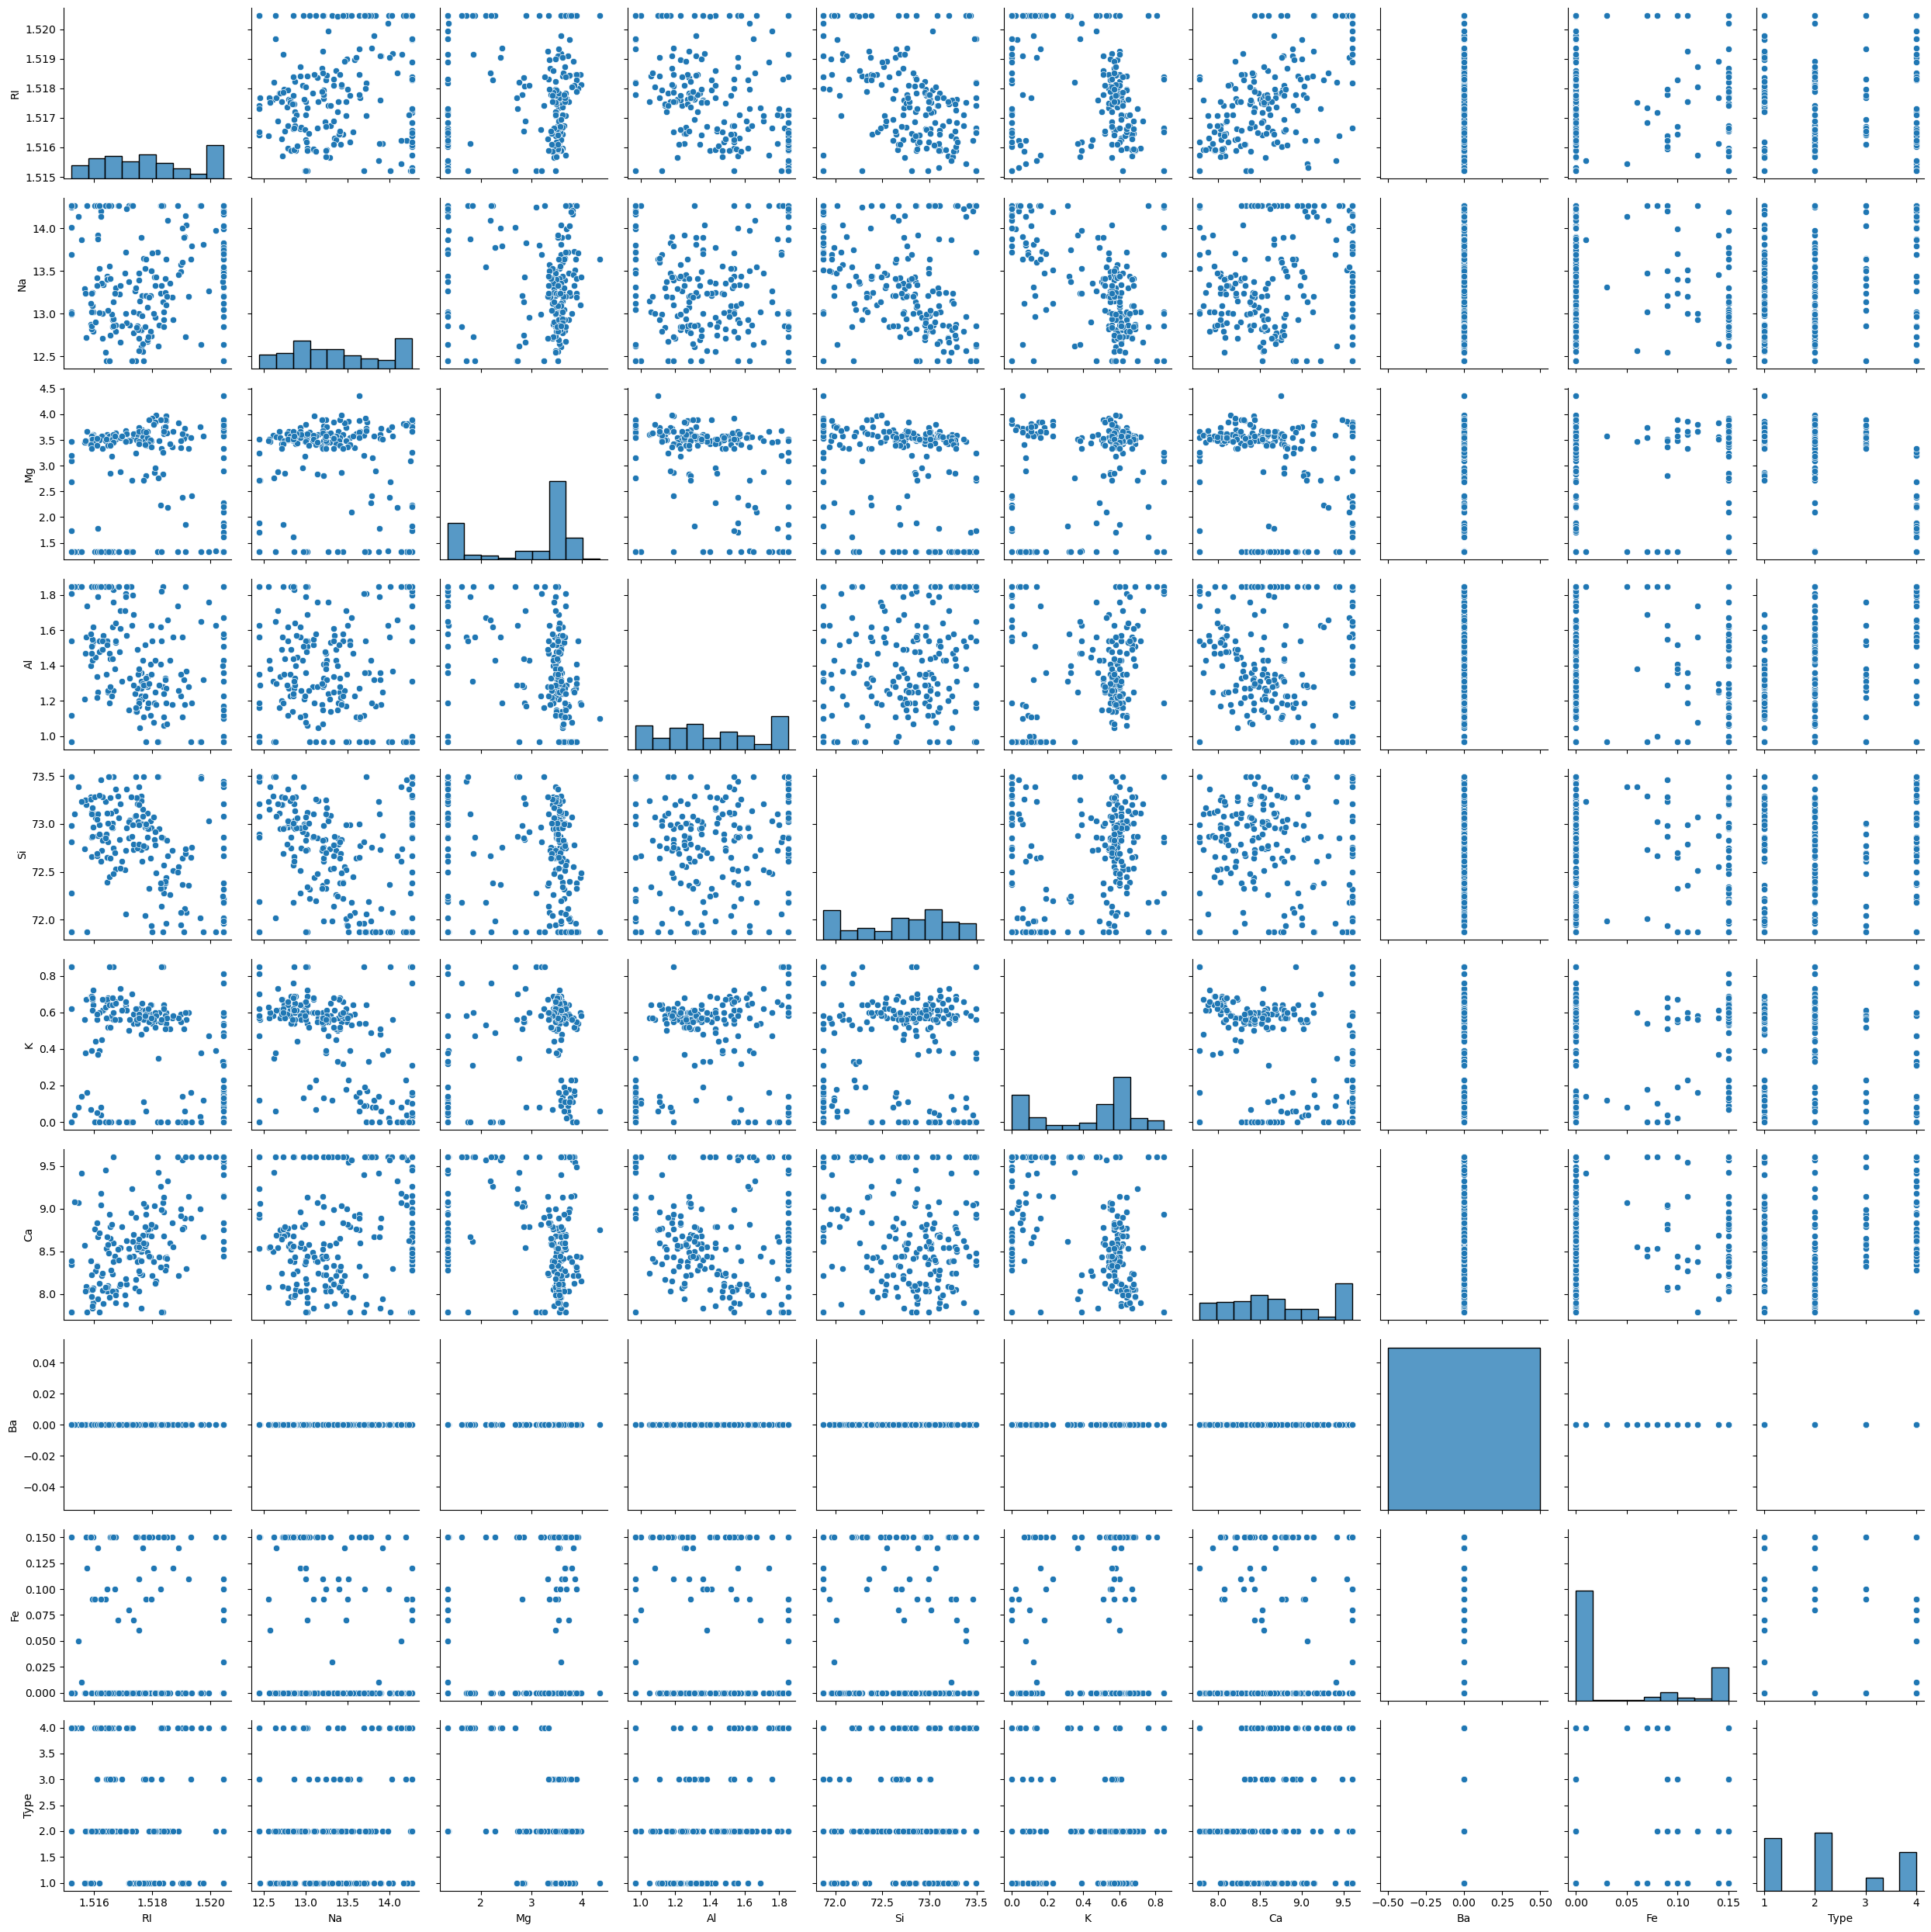

In [22]:
# PAIR PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.pairplot(df)
plt.tight_layout()
plt.show()

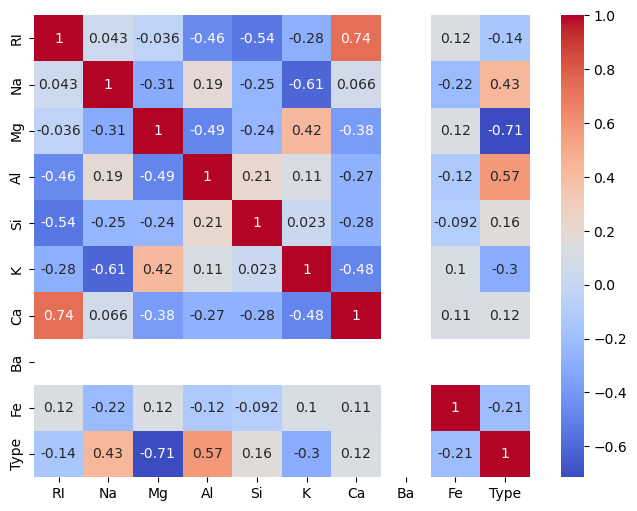

In [23]:
# CORRELATION PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only = True), annot= True, cmap = 'coolwarm')
plt.show()

In [24]:
# 3: Data Preprocessing:
# 1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
# 2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
# 3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.


In [25]:
# Check Missing Values 
missing  = pd.DataFrame({
    "Missing" : df.isnull().sum(),
    "Percentage" : (df.isnull().sum() /len(df)) * 100
})

missing.sort_values("Missing", ascending = False)

,Missing,Percentage
RI,0,0.0
Na,0,0.0
Mg,0,0.0
Al,0,0.0
Si,0,0.0
K,0,0.0
Ca,0,0.0
Ba,0,0.0
Fe,0,0.0
Type,0,0.0


In [26]:
# Check Duplicate Values 
df.duplicated().sum()

np.int64(0)

In [27]:
# Check Categorica columns 
cat_cols = df.select_dtypes(include = 'object').columns
print("Categorical Columns:\n", cat_cols)

Categorical Columns:
 Index([], dtype='object')


In [28]:
# 4: Random Forest Model Implementation:
# 1. Divide the data into train and test split.
# 2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
# 3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

In [29]:
# Extract Feature and Target 
x  = df.drop(columns = 'Type', axis = 1)
y = df['Type']

In [30]:
# Split the Dataset 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state = 42, stratify=y)

In [31]:
# Scaling 
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_teset = scaler.fit(x_train)

In [32]:
# Final Checks 
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (170, 9)
Shape of x_test: (43, 9)
Shape of y_train: (170,)
Shape of y_test: (43,)


In [33]:
# Implementation of Random Forest Classifier
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
             accuracy_score,
             precision_score,
             recall_score,
             f1_score,
             roc_auc_score
)

for leaf in [10,20,25,30,40]:
    rfc = RandomForestClassifier(
                               min_samples_split = 10 ,
                               max_depth = 15,
                               max_leaf_nodes = leaf,
                               random_state = 42
                            )

    # Model Train
    rfc.fit(x_train, y_train)
    
    # Prediction 
    y_pred = rfc.predict(x_test)
    
    # Probability 
    y_prob = rfc.predict_proba(x_test)
    
    print("="*60)
    print(f"RandomForest Classifier\nHyperparameter:\nmin_samples_split = 10\nmax_depth = 15\nmax_leaf_nodes = {leaf}")
    print("---"*10)                         
    
    # Metrics
    # Accuracy Score
    accu_sco = accuracy_score(y_test,y_pred)
    print("Accuracy Score:", accu_sco)
    
    # Precision Score
    pre_sco = precision_score(y_test, y_pred, average = "macro")
    print("Precision Score:",pre_sco)
    
    # Recall Score 
    rec_sco = recall_score(y_test, y_pred, average = "macro")
    print("Recall Score:", rec_sco)
    
    # F1 Score
    f1_sco = f1_score(y_test, y_pred, average = "macro")
    print("F1_Score:", f1_sco)
    
   # ROC_AUC
    y_prob = rfc.predict_proba(x_test)
    roc_auc = roc_auc_score(y_test, 
                            y_prob,
                            multi_class= 'ovr',
                            average = "macro")
    print("ROC AUC:", roc_auc)

RandomForest Classifier
Hyperparameter:
min_samples_split = 10
max_depth = 15
max_leaf_nodes = 10
------------------------------
Accuracy Score: 0.3488372093023256
Precision Score: 0.1685897435897436
Recall Score: 0.2833333333333333
F1_Score: 0.20917874396135266
ROC AUC: 0.6916523132040374
RandomForest Classifier
Hyperparameter:
min_samples_split = 10
max_depth = 15
max_leaf_nodes = 20
------------------------------
Accuracy Score: 0.3023255813953488
Precision Score: 0.09027777777777778
Recall Score: 0.21666666666666667
F1_Score: 0.12745098039215685
ROC AUC: 0.6408956704215325
RandomForest Classifier
Hyperparameter:
min_samples_split = 10
max_depth = 15
max_leaf_nodes = 25
------------------------------
Accuracy Score: 0.3023255813953488
Precision Score: 0.09027777777777778
Recall Score: 0.21666666666666667
F1_Score: 0.12745098039215685
ROC AUC: 0.6408956704215325
RandomForest Classifier
Hyperparameter:
min_samples_split = 10
max_depth = 15
max_leaf_nodes = 30
-------------------------

In [34]:
# 5: Bagging and Boosting Methods:
# Apply the Bagging and Boosting methods and compare the results.

In [39]:
# Bagging 

import warnings

warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
             accuracy_score,
             precision_score,
             recall_score,
             f1_score,
             roc_auc_score
)

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        max_leaf_nodes = 20,
        min_samples_split=5,
        min_samples_leaf=8,
        class_weight="balanced"
    ),
    n_estimators=300,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42
)

# Fit the Model 
bagging_model.fit(x_train,y_train)

# Prediction 
y_pred = bagging_model.predict(x_test)

# Probability 
y_prob = bagging_model.predict_proba(x_test)


print("="*60)
print(f"Bagging Classifier-\nHyperparameter:\nestimator= DecisionTreeClassifier(criterion = 'gini')\nn_estimators = 300\nmax_samples = 0.8\nmax_features= 0.8")
print("---"*10)                         

# Metrics
# Accuracy Score
accu_sco = accuracy_score(y_test,y_pred)
print("Accuracy Score:", accu_sco)


# Precision Score
pre_sco = precision_score(y_test, y_pred, average = "macro")
print("Precision Score:",pre_sco)


# Recall Score 
rec_sco = recall_score(y_test, y_pred, average = "macro")
print("Recall Score:", rec_sco)


# F1 Score
f1_sco = f1_score(y_test, y_pred, average = "macro")
print("F1_Score:", f1_sco)


# ROC_AUC
y_prob = bagging_model.predict_proba(x_test)
roc_auc = roc_auc_score(y_test, 
                        y_prob,
                        multi_class= 'ovr',
                        average = "macro")
print("ROC AUC:", roc_auc)

Bagging Classifier-
Hyperparameter:
estimator= DecisionTreeClassifier(criterion = 'gini')
n_estimators = 300
max_samples = 0.8
max_features= 0.8
------------------------------
Accuracy Score: 0.4418604651162791
Precision Score: 0.21921182266009853
Recall Score: 0.3821428571428571
F1_Score: 0.2761627906976744
ROC AUC: 0.6743384489074145


In [41]:
# Boosting Ada Boost Classifier
from sklearn.ensemble import AdaBoostClassifier
adaboost = AdaBoostClassifier()

# Fit the Model 
adaboost.fit(x_train,y_train)

# Prediction 
boost_y_pred = adaboost.predict(x_test)

# Probability 
y_prob = adaboost.predict_proba(x_test)


print("="*60)
print(f"Boosting Classifier(AdaBoost Classifier)")
print("---"*10)                         

# Metrics
# Accuracy Score
boost_accu_sco = accuracy_score(y_test,boost_y_pred)
print("Accuracy Score:", accu_sco)


# Precision Score
boost_pre_sco = precision_score(y_test, boost_y_pred, average = "macro")
print("Precision Score:",pre_sco)


# Recall Score 
boost_rec_sco = recall_score(y_test, boost_y_pred, average = "macro")
print("Recall Score:", rec_sco)


# F1 Score
boost_f1_sco = f1_score(y_test, boost_y_pred, average = "macro")
print("F1_Score:", f1_sco)


# ROC_AUC
boost_y_prob = adaboost.predict_proba(x_test)
boost_roc_auc = roc_auc_score(y_test, 
                        boost_y_prob,
                        multi_class= 'ovr',
                        average = "macro")
print("ROC AUC:", roc_auc)

Boosting Classifier(AdaBoost Classifier)
------------------------------
Accuracy Score: 0.4418604651162791
Precision Score: 0.21921182266009853
Recall Score: 0.3821428571428571
F1_Score: 0.2761627906976744
ROC AUC: 0.6743384489074145


In [43]:
compare = pd.DataFrame({
    "Comparison": ["Bagging", "Boosting"],
    "Accuracy Score": [accu_sco, boost_accu_sco],
    "Precision Score": [pre_sco, boost_pre_sco],
    "Recall Score": [rec_sco, boost_rec_sco],
    "F1 Score": [f1_sco, boost_f1_sco],
    "ROC AUC": [roc_auc, boost_roc_auc]
}).set_index("Comparison")

compare

,Accuracy Score,Precision Score,Recall Score,F1 Score,ROC AUC
Comparison,,,,,
Bagging,0.441860,0.219212,0.382143,0.276163,0.674338
Boosting,0.325581,0.081395,0.250000,0.122807,0.511512


In [ ]:
# Additional Notes:
# Explain Bagging and Boosting methods. How is it different from each other. | Feature | Bagging | Boosting | | -------------------- | ------------------------------- | ------------------------------------- | | Full form | Bootstrap Aggregating | Boosting | | Training | Parallel/independent | Sequential | | Main focus | Reduce variance | Reduce bias | | Models | Independent | Dependent on previous models | | Data | Random bootstrap samples | Later models focus on previous errors | | Main goal | Reduce overfitting | Improve accuracy | | Speed | Generally faster/parallelizable | Generally slower | | Sensitivity to noise | More robust | Can be sensitive to noisy data | | Example | Random Forest, Bagging | AdaBoost, XGBoost, Gradient Boosting | | Prediction | Voting/Average | Weighted combination |
# 2. Explain how to handle imbalance in the data.
# Imbalanced data occurs when one class has significantly more samples than another class.

# Common methods to handle it are:

# Oversampling: Increase minority-class samples, e.g., using SMOTE.
# Undersampling: Reduce majority-class samples.
# Class Weight: Give more importance to minority classes using class_weight="balanced".
# Stratified Split: Maintain the same class proportions in training and testing data.
# Evaluation Metrics: Use Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix instead of relying only on accuracy.